# Business Case 5 — Seasonal and Weather Adaptations

## Business Objective

Understand whether seasonal and weather conditions are associated with medical appointment attendance patterns.

The objective is to help management:

- Identify seasonal changes in appointment demand
- Understand no-show patterns under different weather conditions
- Support weather-aware scheduling and patient communication
- Identify periods that may require operational adjustments

> This analysis identifies patterns and associations in the historical dataset. It does not establish that weather directly causes appointment no-shows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_weather = pd.read_csv("../../data/Medical_appointment_data.csv")

# Remove exact duplicate rows
df_weather = df_weather.drop_duplicates().copy()

print("Dataset shape:", df_weather.shape)

print("\nWeather-related columns:")
print([
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day',
    'rainy_day_before',
    'storm_day_before',
    'rain_intensity',
    'heat_intensity'
])

print("\nMissing values in weather columns:")
print(
    df_weather[
        [
            'average_temp_day',
            'average_rain_day',
            'max_temp_day',
            'max_rain_day',
            'rainy_day_before',
            'storm_day_before',
            'rain_intensity',
            'heat_intensity'
        ]
    ].isnull().sum()
)

Dataset shape: (109557, 26)

Weather-related columns:
['average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity']

Missing values in weather columns:
average_temp_day    2191
average_rain_day    2225
max_temp_day        2207
max_rain_day        2243
rainy_day_before       0
storm_day_before       0
rain_intensity         0
heat_intensity         0
dtype: int64


In [3]:
# Fill missing continuous weather values with median

weather_numeric_cols = [
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day'
]

for col in weather_numeric_cols:
    df_weather[col] = df_weather[col].fillna(
        df_weather[col].median()
    )

print("Missing values after imputation:")
print(
    df_weather[
        [
            'average_temp_day',
            'average_rain_day',
            'max_temp_day',
            'max_rain_day',
            'rainy_day_before',
            'storm_day_before',
            'rain_intensity',
            'heat_intensity'
        ]
    ].isnull().sum()
)

Missing values after imputation:
average_temp_day    0
average_rain_day    0
max_temp_day        0
max_rain_day        0
rainy_day_before    0
storm_day_before    0
rain_intensity      0
heat_intensity      0
dtype: int64


In [4]:
# Create numeric no-show indicator

df_weather['no_show_numeric'] = (
    df_weather['no_show']
    .map({'no': 0, 'yes': 1})
)

print("No-show distribution:")
print(
    df_weather['no_show_numeric']
    .value_counts()
    .sort_index()
)

print("\nNo-show rate:")
print(
    round(df_weather['no_show_numeric'].mean() * 100, 2),
    "%"
)

No-show distribution:
no_show_numeric
0    74726
1    34831
Name: count, dtype: int64

No-show rate:
31.79 %


In [5]:
# Create month from appointment date

df_weather['appointment_date'] = pd.to_datetime(
    df_weather['appointment_date_continuous']
)

df_weather['appointment_month'] = (
    df_weather['appointment_date'].dt.month
)

monthly_weather = (
    df_weather.groupby('appointment_month')
    .agg(
        total_appointments=('no_show', 'count'),
        no_shows=('no_show_numeric', 'sum')
    )
    .reset_index()
)

monthly_weather['no_show_rate_pct'] = (
    monthly_weather['no_shows']
    / monthly_weather['total_appointments']
    * 100
)

print("Monthly appointment and no-show analysis:")
print(
    monthly_weather
    .round(2)
    .to_string(index=False)
)

Monthly appointment and no-show analysis:
 appointment_month  total_appointments  no_shows  no_show_rate_pct
                 1                8337      2595             31.13
                 2               19536      6165             31.56
                 3               17459      5437             31.14
                 4               15457      4932             31.91
                 5                6238      2037             32.65
                 6                8782      2805             31.94
                 7                9039      2921             32.32
                 8                4711      1512             32.10
                 9                6373      2009             31.52
                10               10735      3442             32.06
                11                 649       208             32.05
                12                2241       768             34.27


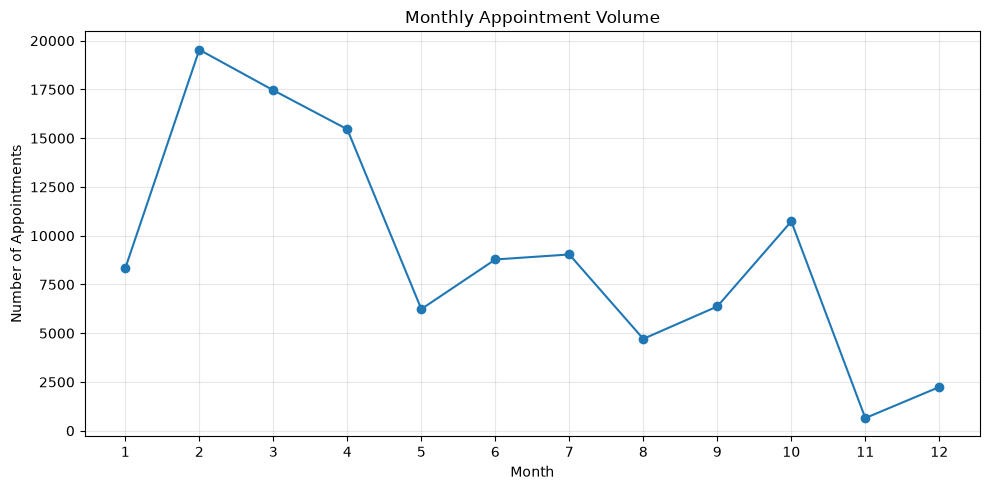

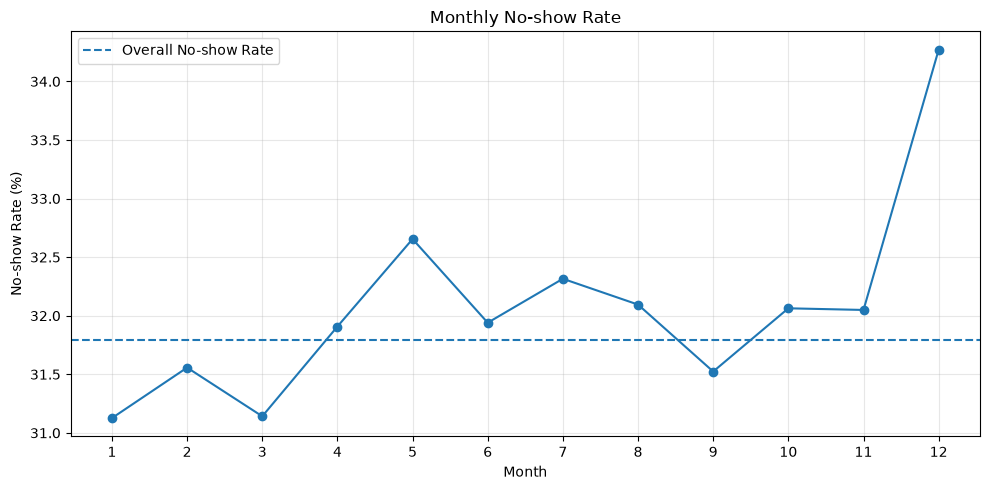

In [6]:
# Chart 1 — Monthly appointment volume

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_weather['appointment_month'],
    monthly_weather['total_appointments'],
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.title('Monthly Appointment Volume')

plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Chart 2 — Monthly no-show rate

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_weather['appointment_month'],
    monthly_weather['no_show_rate_pct'],
    marker='o'
)

plt.axhline(
    df_weather['no_show_numeric'].mean() * 100,
    linestyle='--',
    label='Overall No-show Rate'
)

plt.xlabel('Month')
plt.ylabel('No-show Rate (%)')
plt.title('Monthly No-show Rate')

plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Analyze no-show rates by rain and heat intensity

rain_analysis = (
    df_weather.groupby('rain_intensity', observed=True)
    .agg(
        total_appointments=('no_show', 'count'),
        no_shows=('no_show_numeric', 'sum')
    )
    .reset_index()
)

rain_analysis['no_show_rate_pct'] = (
    rain_analysis['no_shows']
    / rain_analysis['total_appointments']
    * 100
)

heat_analysis = (
    df_weather.groupby('heat_intensity', observed=True)
    .agg(
        total_appointments=('no_show', 'count'),
        no_shows=('no_show_numeric', 'sum')
    )
    .reset_index()
)

heat_analysis['no_show_rate_pct'] = (
    heat_analysis['no_shows']
    / heat_analysis['total_appointments']
    * 100
)

print("No-show rate by Rain Intensity:")
print(
    rain_analysis.round(2).to_string(index=False)
)

print("\nNo-show rate by Heat Intensity:")
print(
    heat_analysis.round(2).to_string(index=False)
)

No-show rate by Rain Intensity:
rain_intensity  total_appointments  no_shows  no_show_rate_pct
         heavy                5756      1886             32.77
      moderate               16250      5396             33.21
       no_rain               76381     23918             31.31
          weak               11170      3631             32.51

No-show rate by Heat Intensity:
heat_intensity  total_appointments  no_shows  no_show_rate_pct
          cold               30186      9572             31.71
    heavy_cold                8310      4408             53.04
    heavy_warm                1730       671             38.79
          mild               46893     12242             26.11
          warm               22438      7938             35.38


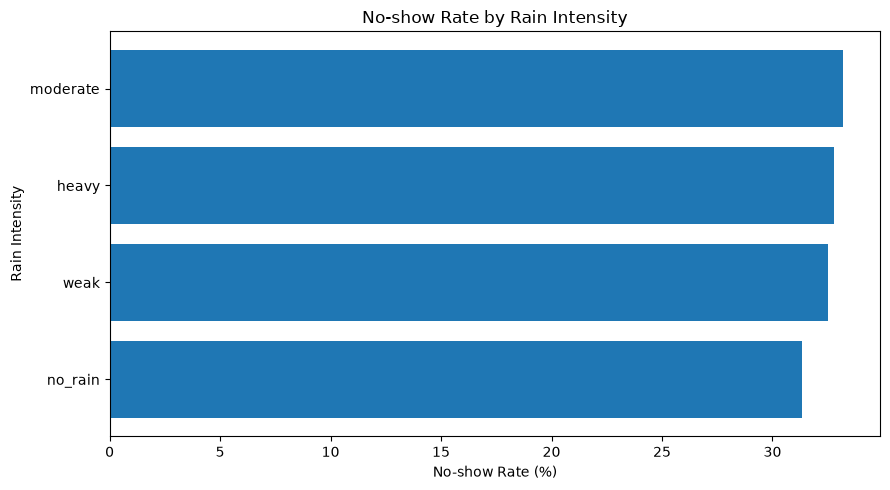

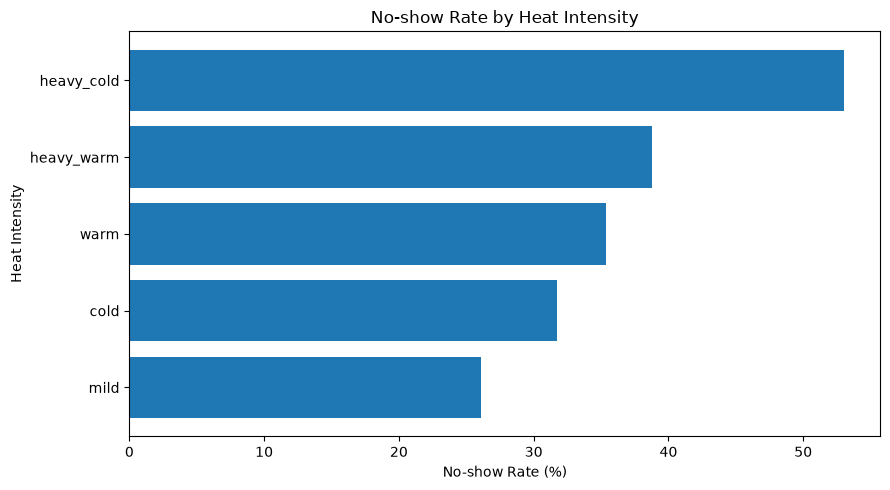

In [8]:
# Chart 1 — No-show rate by rain intensity

rain_plot = rain_analysis.sort_values(
    'no_show_rate_pct',
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    rain_plot['rain_intensity'],
    rain_plot['no_show_rate_pct']
)

plt.xlabel('No-show Rate (%)')
plt.ylabel('Rain Intensity')
plt.title('No-show Rate by Rain Intensity')

plt.tight_layout()
plt.show()


# Chart 2 — No-show rate by heat intensity

heat_plot = heat_analysis.sort_values(
    'no_show_rate_pct',
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    heat_plot['heat_intensity'],
    heat_plot['no_show_rate_pct']
)

plt.xlabel('No-show Rate (%)')
plt.ylabel('Heat Intensity')
plt.title('No-show Rate by Heat Intensity')

plt.tight_layout()
plt.show()

In [9]:
# Analyze previous-day weather conditions

previous_weather = []

for col, label in [
    ('rainy_day_before', 'Rainy Day Before'),
    ('storm_day_before', 'Storm Day Before')
]:
    analysis = (
        df_weather.groupby(col)
        .agg(
            total_appointments=('no_show', 'count'),
            no_shows=('no_show_numeric', 'sum')
        )
        .reset_index()
    )

    analysis['no_show_rate_pct'] = (
        analysis['no_shows']
        / analysis['total_appointments']
        * 100
    )

    analysis['condition'] = label
    previous_weather.append(analysis)

previous_weather_analysis = pd.concat(
    previous_weather,
    ignore_index=True
)

print("No-show rates based on previous-day weather:")
print(
    previous_weather_analysis
    .round(2)
    .to_string(index=False)
)

No-show rates based on previous-day weather:
 rainy_day_before  total_appointments  no_shows  no_show_rate_pct        condition  storm_day_before
              0.0                6841      3849             56.26 Rainy Day Before               NaN
              1.0              102716     30982             30.16 Rainy Day Before               NaN
              NaN                6826      3848             56.37 Storm Day Before               0.0
              NaN              102731     30983             30.16 Storm Day Before               1.0


In [10]:
from scipy.stats import chi2_contingency

# Chi-square test: rainy day before appointment
rain_table = pd.crosstab(
    df_weather['rainy_day_before'],
    df_weather['no_show_numeric']
)

rain_chi2, rain_p, rain_dof, rain_expected = chi2_contingency(
    rain_table
)

# Chi-square test: storm day before appointment
storm_table = pd.crosstab(
    df_weather['storm_day_before'],
    df_weather['no_show_numeric']
)

storm_chi2, storm_p, storm_dof, storm_expected = chi2_contingency(
    storm_table
)

print("Rainy Day Before")
print("Chi-square:", round(rain_chi2, 4))
print("p-value:", round(rain_p, 6))

print("\nStorm Day Before")
print("Chi-square:", round(storm_chi2, 4))
print("p-value:", round(storm_p, 6))

Rainy Day Before
Chi-square: 2013.7821
p-value: 0.0

Storm Day Before
Chi-square: 2027.0116
p-value: 0.0


In [11]:
# Chi-square test for heat intensity and no-show status

heat_table = pd.crosstab(
    df_weather['heat_intensity'],
    df_weather['no_show_numeric']
)

heat_chi2, heat_p, heat_dof, heat_expected = chi2_contingency(
    heat_table
)

print("Heat Intensity vs No-show")
print("Chi-square:", round(heat_chi2, 4))
print("p-value:", heat_p)

Heat Intensity vs No-show
Chi-square: 2602.0929
p-value: 0.0


## Business Insight — Seasonal and Weather Adaptations

The analysis examined seasonal appointment patterns and weather-related factors to understand whether environmental conditions are associated with appointment attendance.

### Key Findings

- The overall no-show rate is **31.79%**.
- Monthly no-show rates remain relatively stable across most months, generally around **31–33%**.
- December recorded the highest monthly no-show rate at **34.27%**, while January and March were around **31.13–31.14%**.
- No-show rates varied only modestly across rain-intensity categories:
  - No rain: **31.31%**
  - Moderate rain: **33.21%**
  - Weak rain: **32.51%**
  - Heavy rain: **32.77%**
- Heat-intensity categories showed larger differences:
  - Mild: **26.11%**
  - Cold: **31.71%**
  - Warm: **35.38%**
  - Heavy warm: **38.79%**
  - Heavy cold: **53.04%**
- A chi-square test found statistically significant associations between no-show status and:
  - Rainy day before appointment: **p < 0.001**
  - Storm day before appointment: **p < 0.001**
  - Heat intensity: **p < 0.001**

### Operational Approach

Healthcare management could use weather information as an additional planning signal:

- Monitor periods with unusual weather conditions.
- Consider additional appointment confirmations during potentially disruptive weather periods.
- Allow flexible rescheduling options when severe environmental conditions occur.
- Combine weather information with patient-level no-show risk rather than using weather alone.
- Monitor attendance patterns over time to determine whether weather-aware interventions improve attendance.

### Business Value

Weather-aware planning can help healthcare organizations prepare for periods where environmental conditions may be associated with changes in attendance and appointment utilization.

> **Important statistical interpretation:** The chi-square tests demonstrate an association between the weather variables and no-show status in this historical dataset. They do **not** prove that weather causes patients to miss appointments.

> The large difference observed across heat-intensity categories should also be interpreted with caution because category sizes differ substantially. In particular, the `heavy_cold` group contains fewer appointments than the larger categories.

> The dataset covers a historical period from **2020 to 2021**. Therefore, these findings should be validated with newer operational data before being used for real-world scheduling decisions.

## Seasonal and Weather Analysis Summary

| Weather / Seasonal Factor | Category | Appointments | No-Shows | No-Show Rate (%) |
|---|---|---:|---:|---:|
| Rain intensity | No rain | 76,381 | 23,918 | 31.31 |
| Rain intensity | Moderate | 16,250 | 5,396 | 33.21 |
| Rain intensity | Weak | 11,170 | 3,631 | 32.51 |
| Rain intensity | Heavy | 5,756 | 1,886 | 32.77 |
| Heat intensity | Mild | 46,893 | 12,242 | 26.11 |
| Heat intensity | Cold | 30,186 | 9,572 | 31.71 |
| Heat intensity | Warm | 22,438 | 7,938 | 35.38 |
| Heat intensity | Heavy warm | 1,730 | 671 | 38.79 |
| Heat intensity | Heavy cold | 8,310 | 4,408 | 53.04 |